In [1]:
import pandas as pd
from scipy import stats

In [2]:
for_df = pd.read_csv("clean_simulation_times(for).csv")
while_df = pd.read_csv("clean_simulation_times(while).csv")

for_times = for_df["second"]
while_times = while_df["second"]

In [3]:
print("--- 基本統計量 ---")
print(f"for   ループの平均時間: {for_times.mean():.6f} 秒")
print(f"while ループの平均時間: {while_times.mean():.6f} 秒")
print(f"差（while - for）     : {while_times.mean() - for_times.mean():.6f} 秒")
print("-" * 18)

--- 基本統計量 ---
for   ループの平均時間: 0.008237 秒
while ループの平均時間: 0.012751 秒
差（while - for）     : 0.004514 秒
------------------


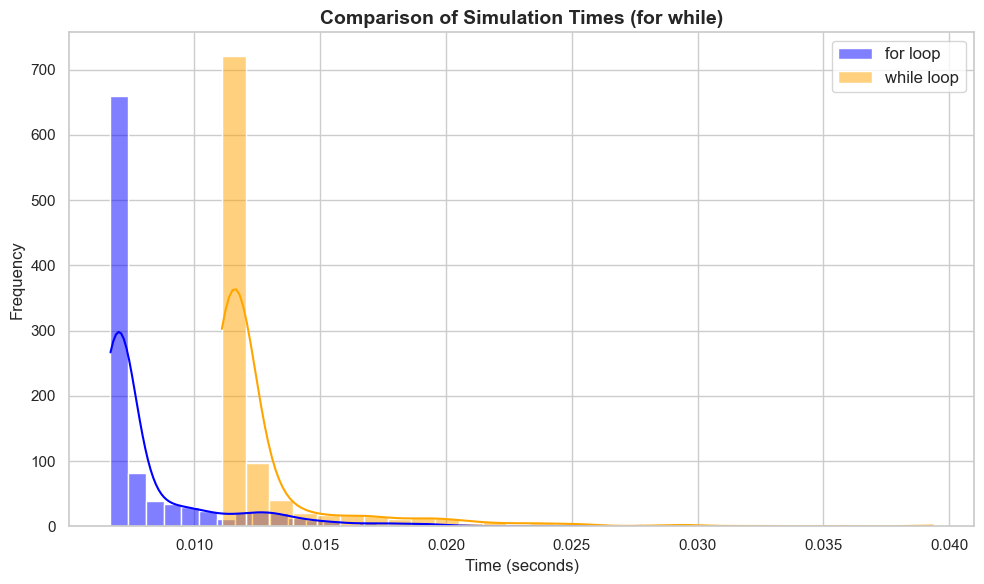

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# グラフのスタイルとサイズの設定
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.histplot(for_times, kde=True, color="blue", label="for loop", alpha=0.5, bins=30)

sns.histplot(while_times, kde=True, color="orange", label="while loop", alpha=0.5, bins=30)

# グラフの装飾
plt.title("Comparison of Simulation Times (for while)", fontsize=14, fontweight='bold')
plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=12)

# グラフの表示
plt.tight_layout()
plt.show()

In [5]:
u_stat, p_value = stats.mannwhitneyu(for_times, while_times, alternative='two-sided')

print("\n--- 統計学的検定結果 ---")
print(f"p値 (p-value): {p_value:.5e}")


--- 統計学的検定結果 ---
p値 (p-value): 1.58261e-209


In [6]:
if p_value < 0.05:
    print("【結論】有意差あり (p < 0.05)")
    print("forループとwhileループの処理速度には、統計的に有意な差が認められます。")
    if for_times.mean() < while_times.mean():
        print("考察: forループの方が有意に高速です。")
    else:
        print("考察: whileループの方が有意に高速です。")
else:
    print("【結論】有意差なし (p >= 0.05)")
    print("forループとwhileループの処理速度の差は、偶然の誤差の範囲内であり、統計的な差は認められません。")

【結論】有意差あり (p < 0.05)
forループとwhileループの処理速度には、統計的に有意な差が認められます。
考察: forループの方が有意に高速です。
